In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Add vllm_exp to path to import log analyzing tools
sys.path.insert(0, '/home/bxb1/vllm_workbench/vllm/vllm_exp')
from log_analysing_tools.analyze_log_metrics import LogMetricsAnalyzer, METRIC_CONFIGS

print("Libraries imported successfully!")
# Define paths for original log files
log_dir = Path('/home/bxb1/vllm_workbench/vllm/logs/project-migration_test_async_flexi_direct_with_no_migration_debug_1.8-200-no-weight-limiter')

flexi_0_log = log_dir / 'server-{pp=32,32}-{flexi=0}.log'
flexi_1_log = log_dir / 'server-{pp=32,32}-{flexi=1}.log'

print(f"Analyzing flexi=0 log: {flexi_0_log.name}")
print(f"Analyzing flexi=1 log: {flexi_1_log.name}")

# Create analyzers for both logs
analyzer_flexi_0 = LogMetricsAnalyzer(str(flexi_0_log))
analyzer_flexi_1 = LogMetricsAnalyzer(str(flexi_1_log))

# Analyze both log files
print("\nAnalyzing flexi=0...")
analyzer_flexi_0.analyze_file()

print("Analyzing flexi=1...")
analyzer_flexi_1.analyze_file()

print("\nAnalysis complete!")# Create a comprehensive comparison visualization
import matplotlib.pyplot as plt
# Function to extract average time in microseconds from a list of time strings
def calculate_avg_time_us(time_strings):
    """Parse time strings and return average in microseconds"""
    if not time_strings:
        return 0
    
    times_us = []
    for time_str in time_strings:
        time_str = time_str.strip()
        # Match patterns like "123µs", "45ms", "1.23 seconds", "1.4e-05s"
        import re
        match = re.match(r'([0-9.eE+-]+)\s*(µs|ms|seconds?|s)', time_str)
        if match:
            value = float(match.group(1))
            unit = match.group(2)
            
            # Convert to microseconds
            if unit in ['µs']:
                time_us = value
            elif unit == 'ms':
                time_us = value * 1000
            elif unit in ['seconds', 'second', 's']:
                time_us = value * 1000000
            else:
                time_us = value
            
            times_us.append(time_us)
    
    return sum(times_us) / len(times_us) if times_us else 0

# Collect metrics from both analyzers
metrics_comparison = {}

for config in METRIC_CONFIGS:
    metric_name = config.name
    display_name = config.display_name
    
    # Get data from both analyzers
    data_flexi_0 = analyzer_flexi_0.metrics.get(metric_name)
    data_flexi_1 = analyzer_flexi_1.metrics.get(metric_name)
    
    # Skip if no data in both
    if not data_flexi_0 and not data_flexi_1:
        continue
    
    # Handle different metric types
    if config.metric_type.value == "keyed_dict":
        # Aggregate all layer data
        all_values_0 = []
        all_values_1 = []
        
        if data_flexi_0:
            for layer_id, values in data_flexi_0.items():
                all_values_0.extend(values)
        
        if data_flexi_1:
            for layer_id, values in data_flexi_1.items():
                all_values_1.extend(values)
        
        avg_0 = calculate_avg_time_us(all_values_0)
        avg_1 = calculate_avg_time_us(all_values_1)
    else:
        # Simple list or special
        avg_0 = calculate_avg_time_us(data_flexi_0 if data_flexi_0 else [])
        avg_1 = calculate_avg_time_us(data_flexi_1 if data_flexi_1 else [])
    
    # Only add if at least one has data
    if avg_0 > 0 or avg_1 > 0:
        metrics_comparison[display_name] = {
            'flexi_0': avg_0,
            'flexi_1': avg_1,
            'count_0': len(data_flexi_0) if isinstance(data_flexi_0, list) else sum(len(v) for v in data_flexi_0.values()) if data_flexi_0 else 0,
            'count_1': len(data_flexi_1) if isinstance(data_flexi_1, list) else sum(len(v) for v in data_flexi_1.values()) if data_flexi_1 else 0
        }

print(f"Found {len(metrics_comparison)} metrics with data")
print("\nSample metrics:")
for i, (name, data) in enumerate(list(metrics_comparison.items())[:5]):
    print(f"  {name}: flexi=0={data['flexi_0']:.2f}µs, flexi=1={data['flexi_1']:.2f}µs")
# Create a comprehensive comparison visualization
import matplotlib.pyplot as plt

from vllm.v1.core.kv_cache_utils import unify_kv_cache_configs

# Filter metrics that have data in both configs
metrics_with_both = {k: v for k, v in metrics_comparison.items() 
                     if v['flexi_0'] > 0 and v['flexi_1'] > 0}

if len(metrics_with_both) == 0:
    print("No metrics found with data in both configurations!")
    print("\nMetrics with data in flexi=0 only:")
    for k, v in metrics_comparison.items():
        if v['flexi_0'] > 0 and v['flexi_1'] == 0:
            print(f"  {k}: {v['flexi_0']:.2f}µs (count={v['count_0']})")
    
    print("\nMetrics with data in flexi=1 only:")
    for k, v in metrics_comparison.items():
        if v['flexi_0'] == 0 and v['flexi_1'] > 0:
            print(f"  {k}: {v['flexi_1']:.2f}µs (count={v['count_1']})")
else:
    print(f"Found {len(metrics_with_both)} metrics with data in both configurations")
    
    # Create comparison dataframe
    comparison_df = pd.DataFrame({
        'Metric': list(metrics_with_both.keys()),
        'Flexi=0 (µs)': [v['flexi_0'] for v in metrics_with_both.values()],
        'Flexi=1 (µs)': [v['flexi_1'] for v in metrics_with_both.values()],
        'Count_0': [v['count_0'] for v in metrics_with_both.values()],
        'Count_1': [v['count_1'] for v in metrics_with_both.values()]
    })
    
    # Calculate percentage change
    comparison_df['Change (%)'] = ((comparison_df['Flexi=1 (µs)'] - comparison_df['Flexi=0 (µs)']) / 
                                    comparison_df['Flexi=0 (µs)'] * 100)
    
    # Sort by absolute change
    comparison_df = comparison_df.sort_values('Change (%)', key=abs, ascending=False)
    
    print("\nTop 10 metrics with largest relative changes:")
    print(comparison_df.head(10)[['Metric', 'Flexi=0 (µs)', 'Flexi=1 (µs)', 'Change (%)']].to_string(index=False))

# Filter metrics that have data in both configs
metrics_with_both = {k: v for k, v in metrics_comparison.items() 
                     if v['flexi_0'] > 0 and v['flexi_1'] > 0}

if len(metrics_with_both) == 0:
    print("No metrics found with data in both configurations!")
    print("\nMetrics with data in flexi=0 only:")
    for k, v in metrics_comparison.items():
        if v['flexi_0'] > 0 and v['flexi_1'] == 0:
            print(f"  {k}: {v['flexi_0']:.2f}µs (count={v['count_0']})")
    
    print("\nMetrics with data in flexi=1 only:")
    for k, v in metrics_comparison.items():
        if v['flexi_0'] == 0 and v['flexi_1'] > 0:
            print(f"  {k}: {v['flexi_1']:.2f}µs (count={v['count_1']})")
else:
    print(f"Found {len(metrics_with_both)} metrics with data in both configurations")
    
    # Create comparison dataframe
    comparison_df = pd.DataFrame({
        'Metric': list(metrics_with_both.keys()),
        'Flexi=0 (µs)': [v['flexi_0'] for v in metrics_with_both.values()],
        'Flexi=1 (µs)': [v['flexi_1'] for v in metrics_with_both.values()],
        'Count_0': [v['count_0'] for v in metrics_with_both.values()],
        'Count_1': [v['count_1'] for v in metrics_with_both.values()]
    })
    
    # Calculate percentage change
    comparison_df['Change (%)'] = ((comparison_df['Flexi=1 (µs)'] - comparison_df['Flexi=0 (µs)']) / 
                                    comparison_df['Flexi=0 (µs)'] * 100)
    
    # Sort by absolute change
    comparison_df = comparison_df.sort_values('Change (%)', key=abs, ascending=False)
    
    print("\nTop 10 metrics with largest relative changes:")
    print(comparison_df.head(10)[['Metric', 'Flexi=0 (µs)', 'Flexi=1 (µs)', 'Change (%)']].to_string(index=False))



Libraries imported successfully!
Analyzing flexi=0 log: server-{pp=32,32}-{flexi=0}.log
Analyzing flexi=1 log: server-{pp=32,32}-{flexi=1}.log

Analyzing flexi=0...
Analyzing log file: /home/bxb1/vllm_workbench/vllm/logs/project-migration_test_async_flexi_direct_with_no_migration_debug_1.8-200-no-weight-limiter/server-{pp=32,32}-{flexi=0}.log
Finished parsing log file.

Analyzing flexi=1...
Analyzing log file: /home/bxb1/vllm_workbench/vllm/logs/project-migration_test_async_flexi_direct_with_no_migration_debug_1.8-200-no-weight-limiter/server-{pp=32,32}-{flexi=1}.log
Finished parsing log file.


Analysis complete!
Found 18 metrics with data

Sample metrics:
  Migration Process Times: flexi=0=15000000.00µs, flexi=1=16900000.00µs
  Engine Locking Times (During Migration): flexi=0=15000.00µs, flexi=1=15000.00µs
  Compact KV Cache Times (Within Lock): flexi=0=676500.00µs, flexi=1=52500.00µs
  Bind KV Cache Times (During Migration): flexi=0=0.00µs, flexi=1=286.97µs
  Getting Model Lock Taki

/data/gpfs/projects/punim2715/vllm_workbench/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


INFO 01-19 14:48:56 [__init__.py:243] Automatically detected platform cuda.


2026-01-19 14:48:59,280	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Found 17 metrics with data in both configurations

Top 10 metrics with largest relative changes:
                                           Metric  Flexi=0 (µs)  Flexi=1 (µs)  Change (%)
             Compact KV Cache Times (Within Lock)  6.765000e+05  5.250000e+04  -92.239468
         Weight Loading Time (Individual Weights)  5.351691e+04  2.406136e+04  -55.039716
                      Getting Forward Lock Taking  8.181290e-01  3.729895e-01  -54.409456
[CompiledDAG] WRITE Forward Lock Acquisition Time  4.536781e+01  6.728480e+01   48.309570
    [RAY.NCCLGROUP.Send] Send Queued To Peer Time  4.106711e+01  3.075042e+01  -25.121553
     [Ray.Comm.Read] Tensor Metadata Receive Time  8.068105e+03  6.916999e+03  -14.267357
                          Migration Process Times  1.500000e+07  1.690000e+07   12.666667
            [Ray.Comm.Read] Tensors Received Time  1.072690e+04  9.607518e+03  -10.435260
                        Getting Model Lock Taking  1.200174e+00  1.100666e+00   -8.291192
   


Plot saved to: /home/bxb1/vllm_workbench/vllm/logs/project-migration_test_async_flexi_direct_with_no_migration_debug_1.8-200-no-weight-limiter/metrics_comparison_flexi_0_vs_1.png

Priority metrics shown: 5/5
  ✓ Compact KV Cache Times (Within Lock)
  ✓ Process Engine Step Time
  ✓ Weight Loading Time (Individual Weights)
  ✓ [CompiledDAG] READ Completion Time
  ✓ After Forwarding Took


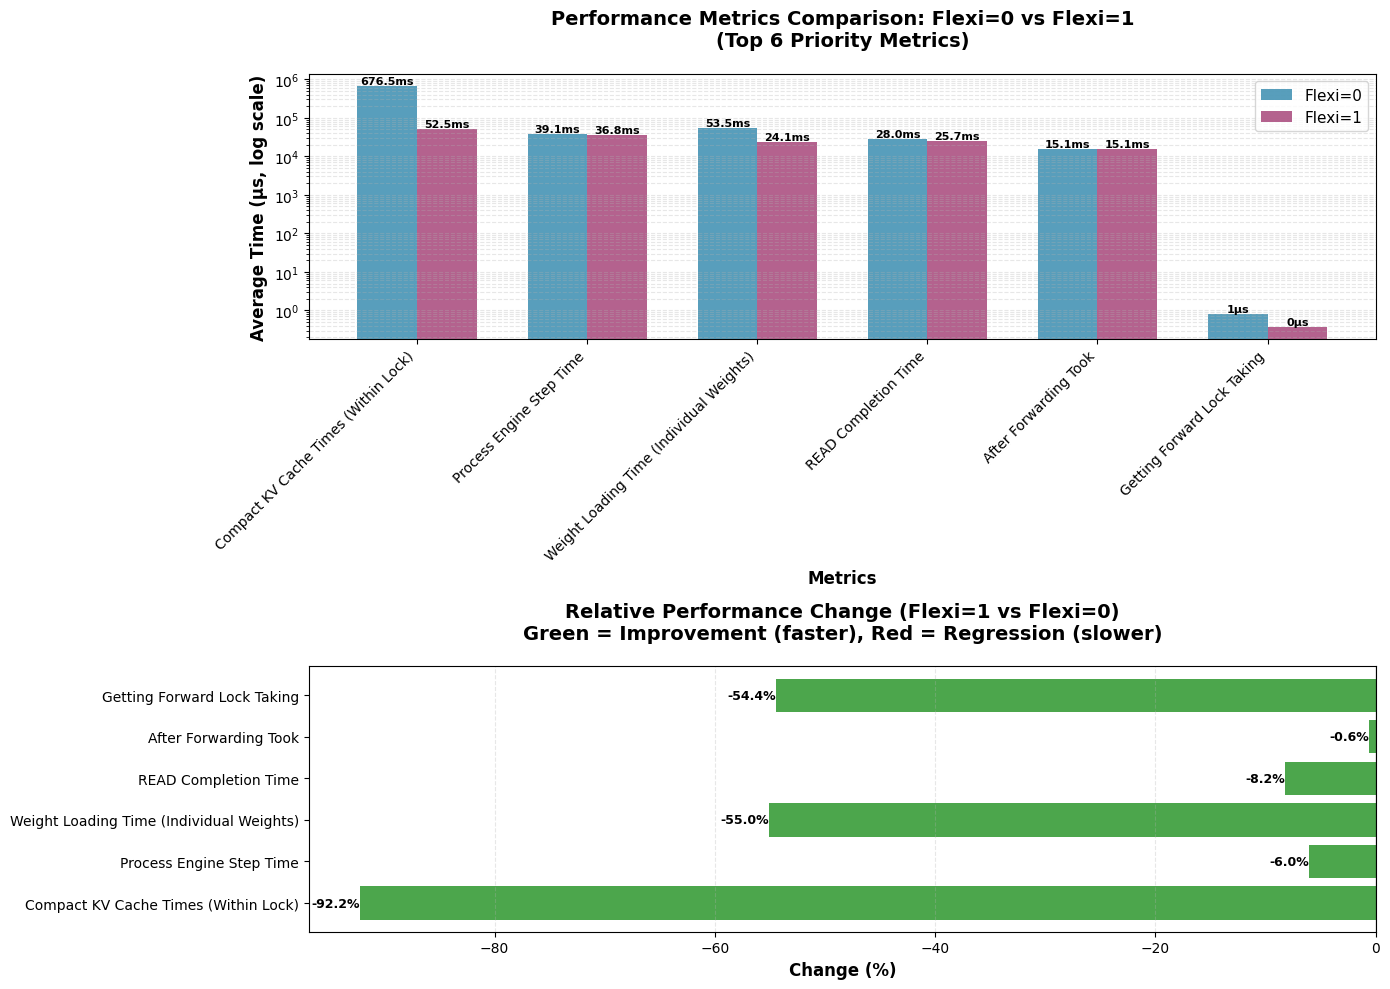

In [2]:
Top_Metrics = 6
# Create the main comparison bar chart
if len(metrics_with_both) > 0:
    # Define priority metrics to show first
    priority_metrics = [
        'Compact KV Cache Times (Within Lock)',
        'Process Engine Step Time',
        'Weight Loading Time (Individual Weights)',
        '[CompiledDAG] READ Completion Time',
        'After Forwarding Took'
    ]
    
    # Separate priority and other metrics
    priority_rows = []
    other_rows = []
    
    for idx, row in comparison_df.iterrows():
        if row['Metric'] in priority_metrics:
            priority_rows.append(row)
        else:
            other_rows.append(row)
    
    # Create dataframe with priority metrics first
    if priority_rows:
        priority_df = pd.DataFrame(priority_rows)
        # Sort priority metrics by their order in the priority list
        priority_df['priority_order'] = priority_df['Metric'].apply(
            lambda x: priority_metrics.index(x) if x in priority_metrics else 999
        )
        priority_df = priority_df.sort_values('priority_order').drop('priority_order', axis=1)
    else:
        priority_df = pd.DataFrame()
    
    if other_rows:
        other_df = pd.DataFrame(other_rows)
        # Sort others by absolute change
        other_df = other_df.sort_values('Change (%)', key=abs, ascending=False)
    else:
        other_df = pd.DataFrame()
    
    # Combine: priority metrics first, then top others (total 8 metrics)
    if not priority_df.empty and not other_df.empty:
        remaining_slots = max(0, Top_Metrics - len(priority_df))
        plot_df = pd.concat([priority_df, other_df.head(remaining_slots)], ignore_index=True)
    elif not priority_df.empty:
        plot_df = priority_df.head(Top_Metrics)
    else:
        plot_df = other_df.head(Top_Metrics)
    
    # Create figure
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
    
    # Plot 1: Absolute values comparison with log scale
    x = np.arange(len(plot_df))
    width = 0.35
    
    # Shorten metric names for better display
    short_names = [name.split(']')[-1].strip() if ']' in name else name[:40] 
                   for name in plot_df['Metric']]
    
    bars1 = ax1.bar(x - width/2, plot_df['Flexi=0 (µs)'], width, 
                    label='Flexi=0', alpha=0.8, color='#2E86AB')
    bars2 = ax1.bar(x + width/2, plot_df['Flexi=1 (µs)'], width, 
                    label='Flexi=1', alpha=0.8, color='#A23B72')
    
    ax1.set_xlabel('Metrics', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Average Time (µs, log scale)', fontsize=12, fontweight='bold')
    ax1.set_title(f'Performance Metrics Comparison: Flexi=0 vs Flexi=1\n(Top {Top_Metrics} Priority Metrics)', 
                  fontsize=14, fontweight='bold', pad=20)
    ax1.set_xticks(x)
    ax1.set_xticklabels(short_names, rotation=45, ha='right', fontsize=10)
    ax1.legend(fontsize=11)
    ax1.set_yscale('log')  # Set y-axis to log scale
    ax1.grid(axis='y', alpha=0.3, linestyle='--', which='both')
    
    # Add value labels on bars
    def add_value_labels(ax, bars):
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                # Format based on magnitude
                if height >= 1000000:
                    label = f'{height/1000000:.2f}s'
                elif height >= 1000:
                    label = f'{height/1000:.1f}ms'
                else:
                    label = f'{height:.0f}µs'
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       label, ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    add_value_labels(ax1, bars1)
    add_value_labels(ax1, bars2)
    
    # Plot 2: Percentage change
    colors = ['green' if x < 0 else 'red' for x in plot_df['Change (%)']]
    bars3 = ax2.barh(range(len(plot_df)), plot_df['Change (%)'], 
                     color=colors, alpha=0.7)
    
    ax2.set_yticks(range(len(plot_df)))
    ax2.set_yticklabels(short_names, fontsize=10)
    ax2.set_xlabel('Change (%)', fontsize=12, fontweight='bold')
    ax2.set_title('Relative Performance Change (Flexi=1 vs Flexi=0)\nGreen = Improvement (faster), Red = Regression (slower)', 
                  fontsize=14, fontweight='bold', pad=20)
    ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    ax2.grid(axis='x', alpha=0.3, linestyle='--')
    
    # Add percentage labels
    for i, (idx, row) in enumerate(plot_df.iterrows()):
        change = row['Change (%)']
        label = f'{change:+.1f}%'
        ax2.text(change, i, label, ha='left' if change > 0 else 'right', 
                va='center', fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(log_dir / 'metrics_comparison_flexi_0_vs_1.png', dpi=300, bbox_inches='tight')
    print(f"\nPlot saved to: {log_dir / 'metrics_comparison_flexi_0_vs_1.png'}")
    
    # Print which priority metrics were found
    print(f"\nPriority metrics shown: {len(priority_df) if not priority_df.empty else 0}/{len(priority_metrics)}")
    for pm in priority_metrics:
        found = pm in plot_df['Metric'].values
        print(f"  {'✓' if found else '✗'} {pm}")
    
    plt.show()


Flexi=0 data shape: (200, 5)
Flexi=1 data shape: (200, 5)

Columns: ['timestamp', 'datetime', 'tpots', 'ttfts', 'e2els']

First few rows of flexi=0:
      timestamp                 datetime     tpots     ttfts     e2els
0  1.768794e+09  2026-01-19 14:45:56.993  0.097746  0.287702  6.445699
1  1.768794e+09  2026-01-19 14:45:57.498  0.099350  0.315255  6.574295
2  1.768794e+09  2026-01-19 14:45:58.143  0.104734  0.339821  6.938088
3  1.768794e+09  2026-01-19 14:45:58.655  0.105828  0.322533  6.989679
4  1.768794e+09  2026-01-19 14:45:59.192  0.107312  0.343187  7.103814

Time series plot saved to: /home/bxb1/vllm_workbench/vllm/logs/project-migration_test_async_flexi_direct_with_no_migration_debug_1.8-200-no-weight-limiter/request_metrics_time_series_comparison.png


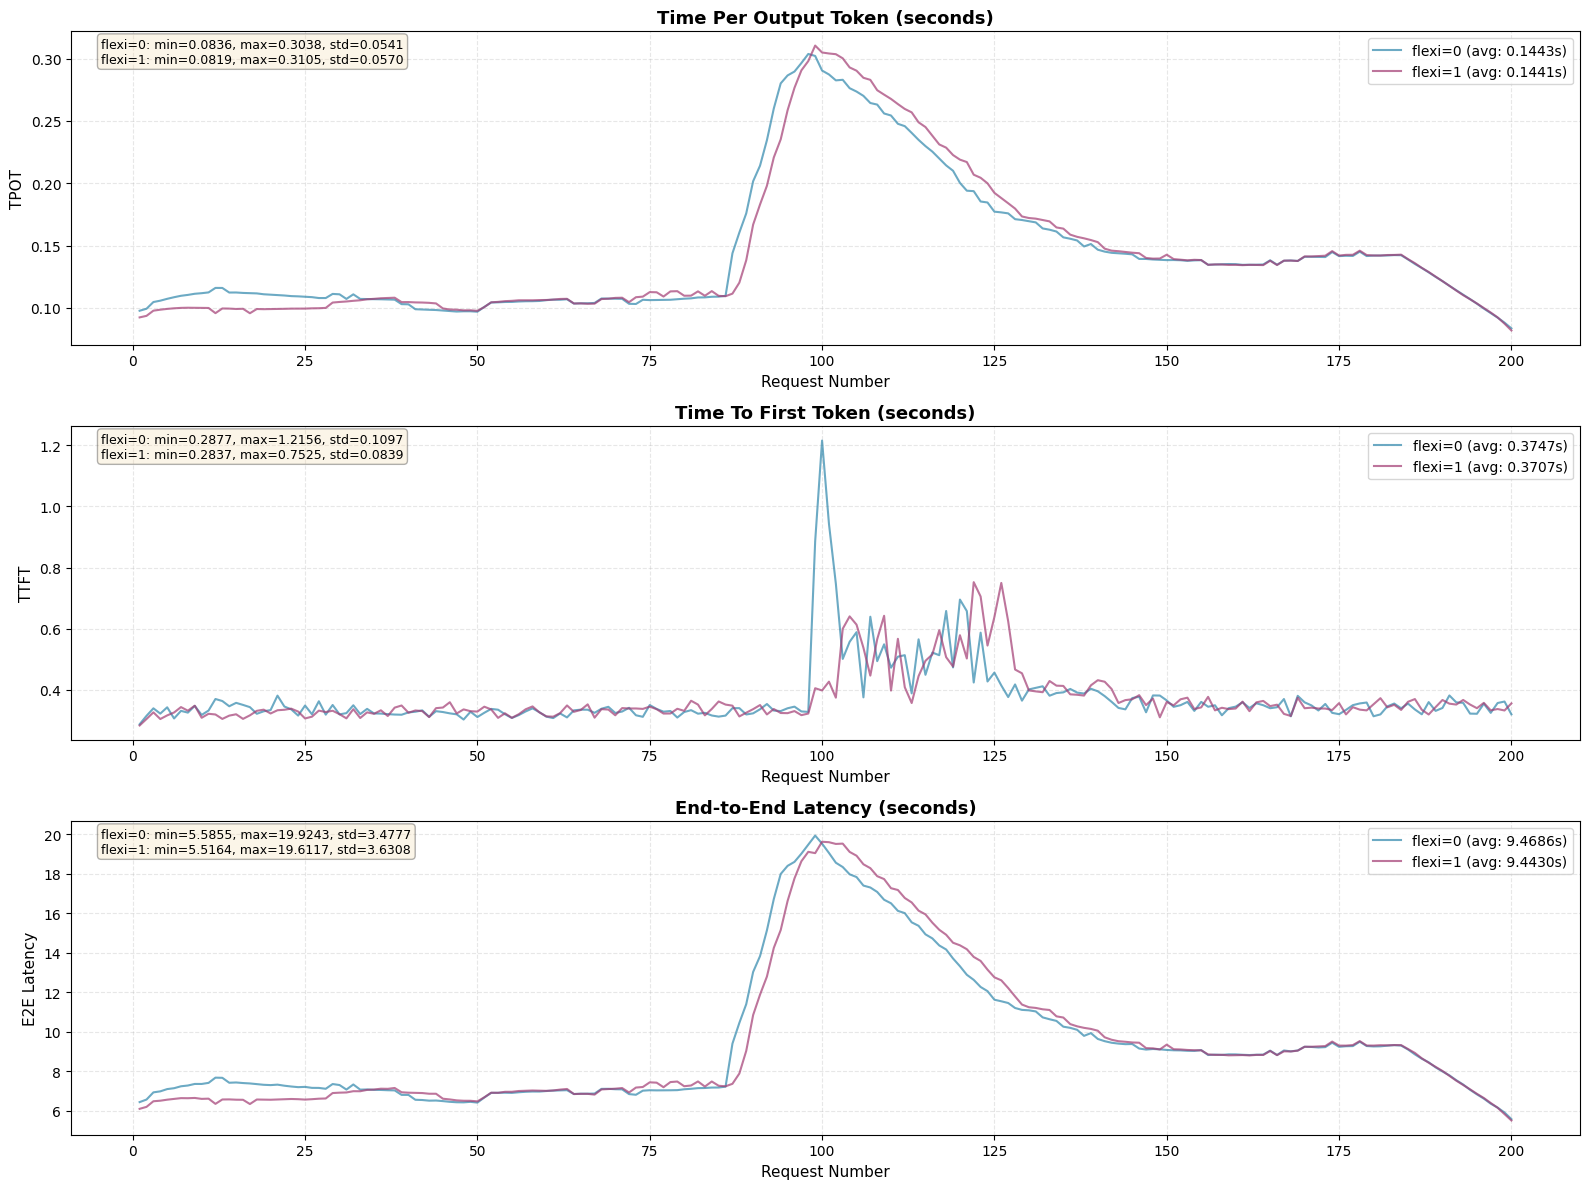


SUMMARY STATISTICS

TPOT:
  flexi=0: mean=0.144347s, median=0.133315s
  flexi=1: mean=0.144078s, median=0.127001s
  Change: -0.19%

TTFT:
  flexi=0: mean=0.374719s, median=0.340709s
  flexi=1: mean=0.370739s, median=0.340193s
  Change: -1.06%

E2E Latency:
  flexi=0: mean=9.468593s, median=8.732473s
  flexi=1: mean=9.443010s, median=8.332744s
  Change: -0.27%


In [3]:

# Load time series data from request metrics CSV files
import pandas as pd

flexi_0_csv = log_dir / 'request_metrics-{pp=32,32}-{flexi=0}.csv'
flexi_1_csv = log_dir / 'request_metrics-{pp=32,32}-{flexi=1}.csv'

# Read CSV files
df_flexi_0 = pd.read_csv(flexi_0_csv)
df_flexi_1 = pd.read_csv(flexi_1_csv)

print(f"Flexi=0 data shape: {df_flexi_0.shape}")
print(f"Flexi=1 data shape: {df_flexi_1.shape}")
print(f"\nColumns: {df_flexi_0.columns.tolist()}")
print(f"\nFirst few rows of flexi=0:")
print(df_flexi_0.head())

# Create time series plots comparing flexi=0 and flexi=1
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Add request index (starting from 1)
df_flexi_0['request_index'] = range(1, len(df_flexi_0) + 1)
df_flexi_1['request_index'] = range(1, len(df_flexi_1) + 1)

# Metric configurations for plotting
metrics = [
    ('tpots', 'Time Per Output Token (seconds)', 'TPOT'),
    ('ttfts', 'Time To First Token (seconds)', 'TTFT'),
    ('e2els', 'End-to-End Latency (seconds)', 'E2E Latency')
]

colors_flexi = ['#2E86AB', '#A23B72']  # Blue for flexi=0, Purple for flexi=1

for idx, (metric_col, title, ylabel) in enumerate(metrics):
    ax = axes[idx]
    
    # Plot flexi=0
    ax.plot(df_flexi_0['request_index'], df_flexi_0[metric_col], 
            label=f'flexi=0 (avg: {df_flexi_0[metric_col].mean():.4f}s)',
            color=colors_flexi[0], alpha=0.7, linewidth=1.5)
    
    # Plot flexi=1
    ax.plot(df_flexi_1['request_index'], df_flexi_1[metric_col], 
            label=f'flexi=1 (avg: {df_flexi_1[metric_col].mean():.4f}s)',
            color=colors_flexi[1], alpha=0.7, linewidth=1.5)
    
    ax.set_xlabel('Request Number', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Add statistics text box
    stats_text = f'flexi=0: min={df_flexi_0[metric_col].min():.4f}, max={df_flexi_0[metric_col].max():.4f}, std={df_flexi_0[metric_col].std():.4f}\n'
    stats_text += f'flexi=1: min={df_flexi_1[metric_col].min():.4f}, max={df_flexi_1[metric_col].max():.4f}, std={df_flexi_1[metric_col].std():.4f}'
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
save_path = log_dir / 'request_metrics_time_series_comparison.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'\nTime series plot saved to: {save_path}')
plt.show()

# Print summary statistics
print('\n' + '='*80)
print('SUMMARY STATISTICS')
print('='*80)
for metric_col, _, ylabel in metrics:
    print(f'\n{ylabel}:')
    print(f'  flexi=0: mean={df_flexi_0[metric_col].mean():.6f}s, median={df_flexi_0[metric_col].median():.6f}s')
    print(f'  flexi=1: mean={df_flexi_1[metric_col].mean():.6f}s, median={df_flexi_1[metric_col].median():.6f}s')
    change = ((df_flexi_1[metric_col].mean() - df_flexi_0[metric_col].mean()) / df_flexi_0[metric_col].mean()) * 100
    print(f'  Change: {change:+.2f}%')

Process Engine Step Time:
  flexi=0: 3444 data points
  flexi=1: 3608 data points
After Forwarding Took:
  flexi=0: 3442 data points
  flexi=1: 3606 data points
Communication Time from Upstream:
  flexi=0: 1721 data points
  flexi=1: 1803 data points
[Ray.Comm.Read] Tensors Received Time:
  flexi=0: 1721 data points
  flexi=1: 1803 data points
[RAY.NCCLGROUP.Read] Recv Buffer Allocation Time:
  flexi=0: 3442 data points
  flexi=1: 3606 data points
[RAY.NCCLGROUP.Read] Received Data From Comm Time:
  flexi=0: 3442 data points
  flexi=1: 3606 data points

Extracted time series data for 6 metrics

Time series plot saved to: /home/bxb1/vllm_workbench/vllm/logs/project-migration_test_async_flexi_direct_with_no_migration_debug_1.8-200-no-weight-limiter/analysis_metrics_time_series_comparison.png


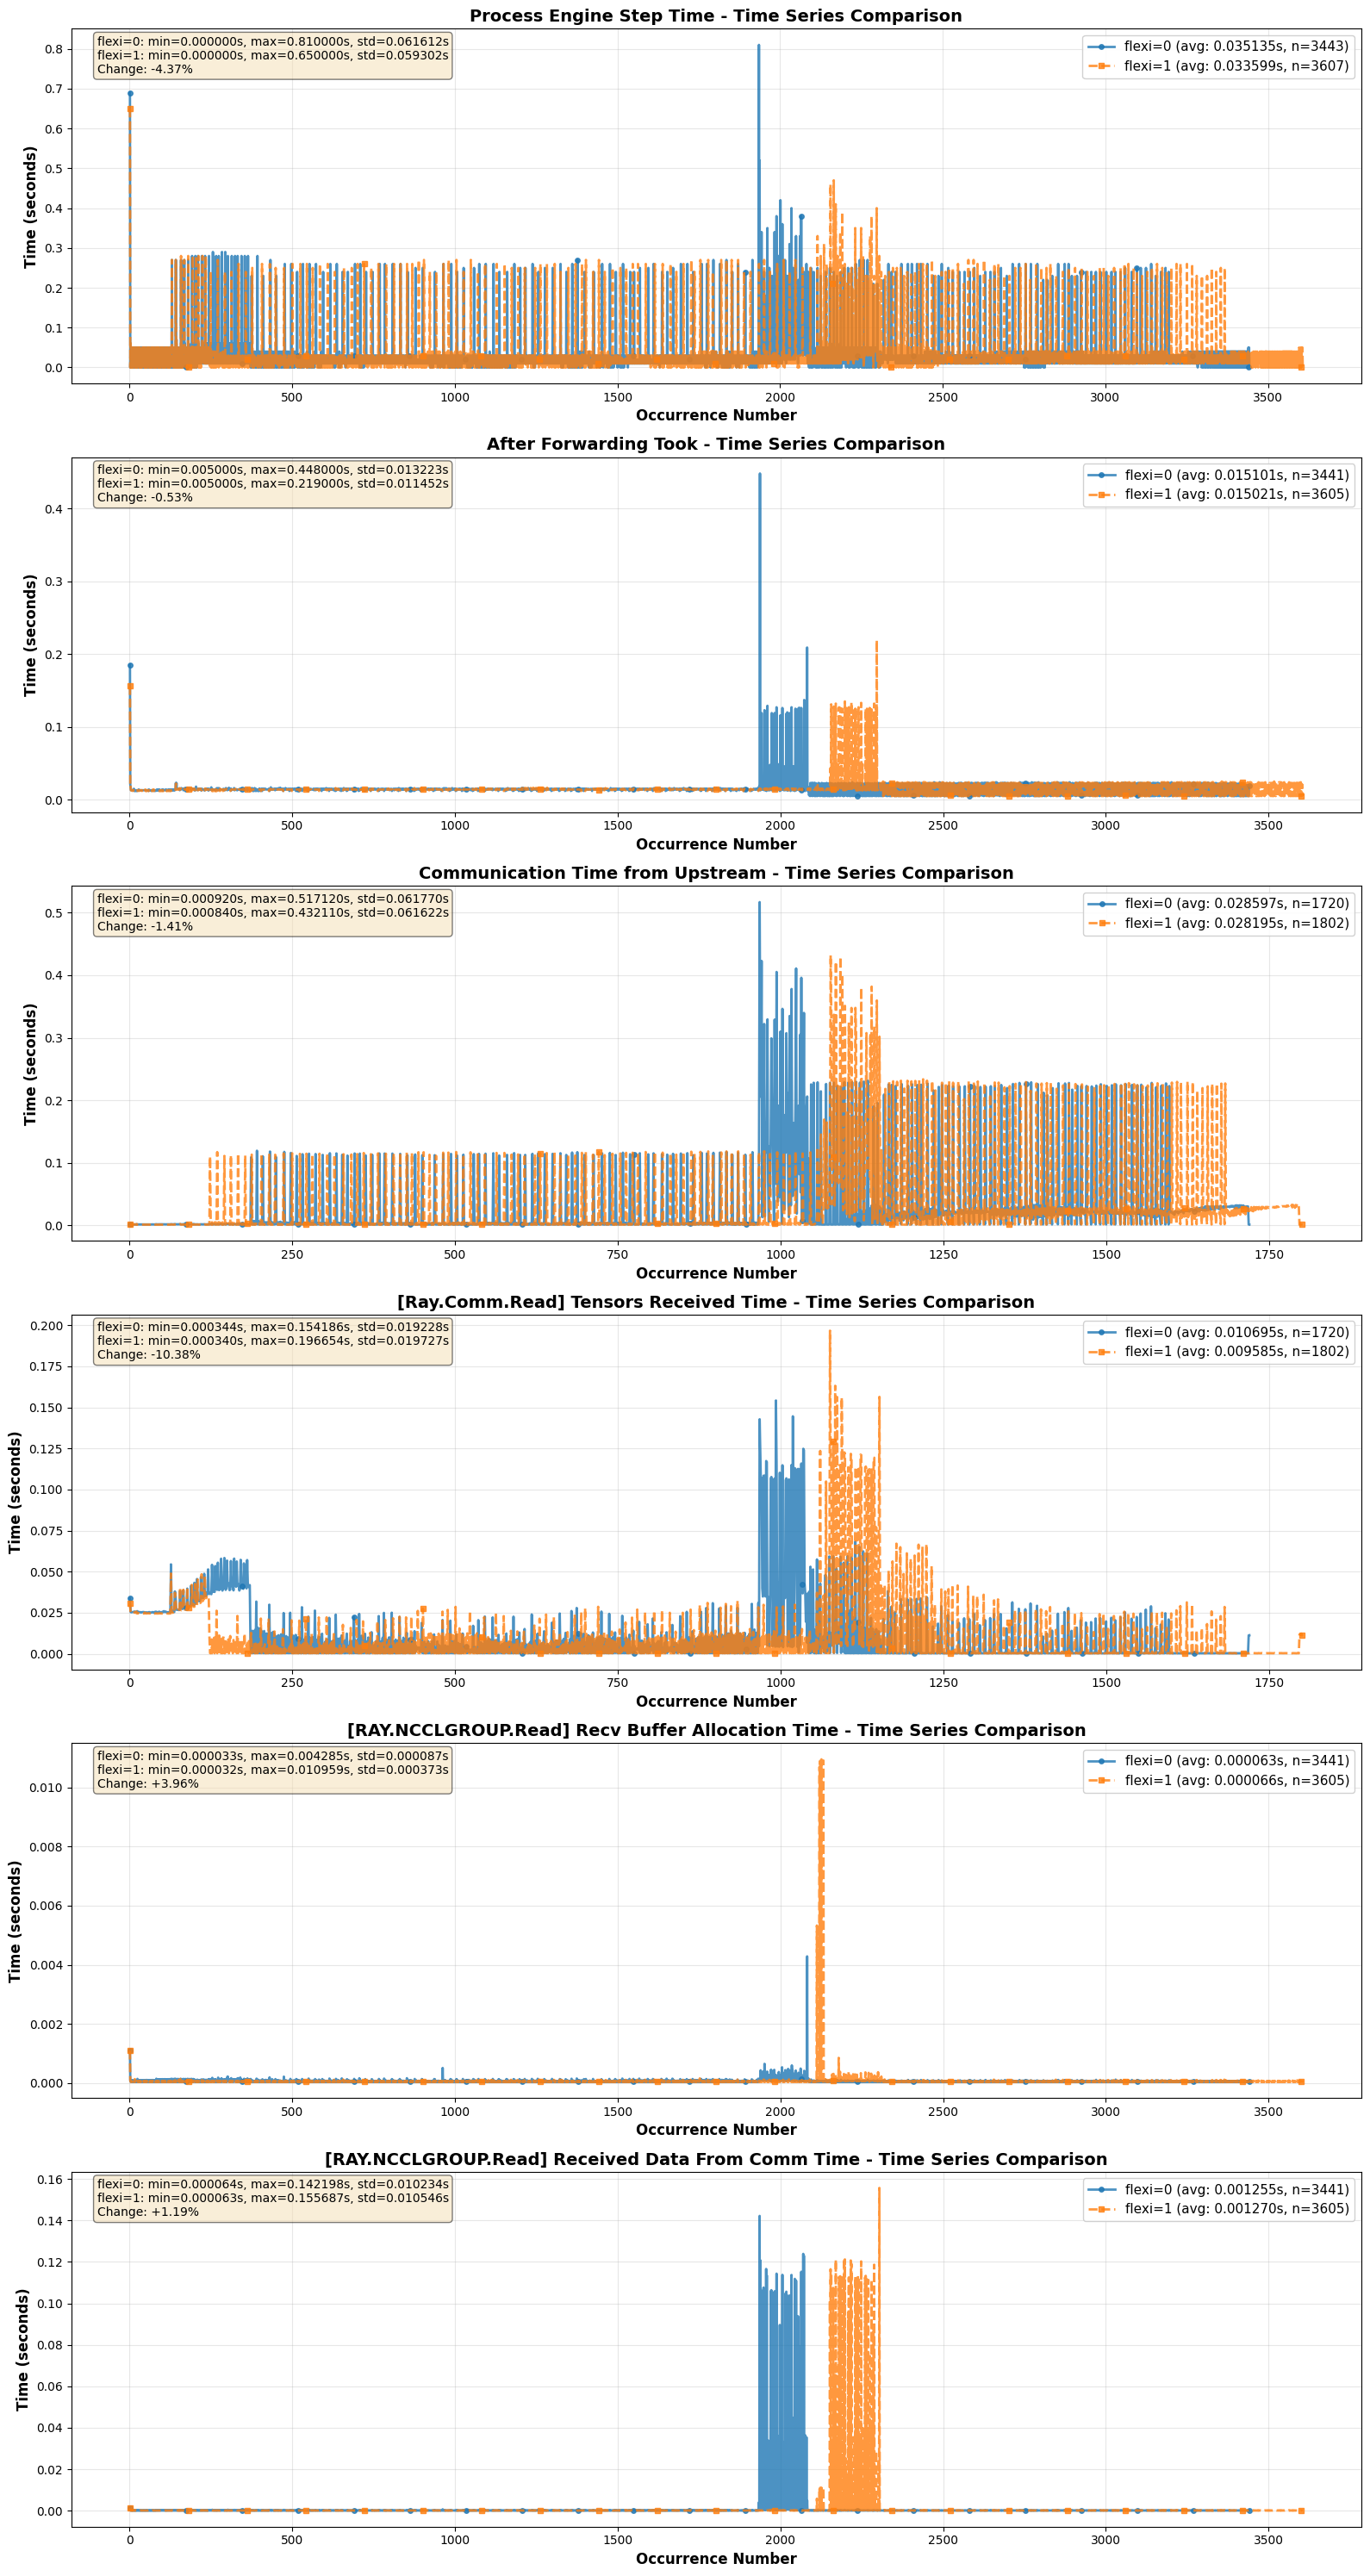


DETAILED STATISTICS FOR ANALYSIS LOG METRICS

Process Engine Step Time:
  flexi=0: mean=0.039109s, median=0.020000s, min=0.000000s, max=13.720000s
  flexi=1: mean=0.036757s, median=0.020000s, min=0.000000s, max=11.430000s
  Mean change: -6.01%

After Forwarding Took:
  flexi=0: mean=0.015145s, median=0.014000s, min=0.005000s, max=0.448000s
  flexi=1: mean=0.015060s, median=0.014000s, min=0.005000s, max=0.219000s
  Mean change: -0.56%

Communication Time from Upstream:
  flexi=0: mean=0.028590s, median=0.003280s, min=0.000920s, max=0.517120s
  flexi=1: mean=0.028188s, median=0.002820s, min=0.000840s, max=0.432110s
  Mean change: -1.40%

[Ray.Comm.Read] Tensors Received Time:
  flexi=0: mean=0.010727s, median=0.000578s, min=0.000344s, max=0.154186s
  flexi=1: mean=0.009608s, median=0.000491s, min=0.000340s, max=0.196654s
  Mean change: -10.44%

[RAY.NCCLGROUP.Read] Recv Buffer Allocation Time:
  flexi=0: mean=0.000063s, median=0.000055s, min=0.000033s, max=0.004285s
  flexi=1: mean=0.00

In [4]:
# Extract time series data for specific metrics from analysis logs
import re

X_AXIS_MIN = None  # 例如：1
X_AXIS_MAX = None   # 例如：5001201
def extract_time_series_from_metric(metric_data, metric_type="list"):
    """Extract time series values from metric data"""
    if not metric_data:
        return []
    
    values = []
    if metric_type == "keyed_dict":
        # Aggregate all layer data
        for layer_id, time_strings in metric_data.items():
            for time_str in time_strings:
                values.append(parse_time_to_seconds(time_str))
    else:
        # Simple list
        for time_str in metric_data:
            values.append(parse_time_to_seconds(time_str))
    
    return values

def parse_time_to_seconds(time_str):
    """Parse time string and return value in seconds"""
    time_str = time_str.strip()
    match = re.match(r'([0-9.eE+-]+)\s*(µs|ms|seconds?|s)', time_str)
    if match:
        value = float(match.group(1))
        unit = match.group(2)
        
        # Convert to seconds
        if unit in ['µs']:
            return value / 1_000_000
        elif unit == 'ms':
            return value / 1000
        elif unit in ['seconds', 'second', 's']:
            return value
    return 0

# Specify the metrics we want to plot
target_metrics = [
    'Process Engine Step Time',
    'After Forwarding Took',
    'Communication Time from Upstream',
    '[Ray.Comm.Read] Tensors Received Time',
    '[RAY.NCCLGROUP.Read] Recv Buffer Allocation Time',
    '[RAY.NCCLGROUP.Read] Received Data From Comm Time'
]

# Extract time series data for each metric
metric_time_series = {}

for config in METRIC_CONFIGS:
    if config.display_name in target_metrics:
        metric_name = config.name
        display_name = config.display_name
        
        # Get data from both analyzers
        data_flexi_0 = analyzer_flexi_0.metrics.get(metric_name)
        data_flexi_1 = analyzer_flexi_1.metrics.get(metric_name)
        
        metric_time_series[display_name] = {
            'flexi_0': extract_time_series_from_metric(data_flexi_0, config.metric_type.value),
            'flexi_1': extract_time_series_from_metric(data_flexi_1, config.metric_type.value)
        }
        
        print(f"{display_name}:")
        print(f"  flexi=0: {len(metric_time_series[display_name]['flexi_0'])} data points")
        print(f"  flexi=1: {len(metric_time_series[display_name]['flexi_1'])} data points")

print(f"\nExtracted time series data for {len(metric_time_series)} metrics")

# Create time series plots for specified metrics from analysis logs
fig, axes = plt.subplots(len(target_metrics), 1, figsize=(16, 5 * len(target_metrics)))

# Ensure axes is always a list
if len(target_metrics) == 1:
    axes = [axes]

# Use distinct colors and line styles
colors_flexi = ['#1f77b4', '#ff7f0e']  # Blue and Orange for better contrast
line_styles = ['-', '--']  # Solid and dashed
markers = ['o', 's']  # Circle and square
marker_sizes = [4, 4]

for idx, metric_name in enumerate(target_metrics):
    ax = axes[idx]
    
    if metric_name not in metric_time_series:
        ax.text(0.5, 0.5, f'No data available for {metric_name}', 
                ha='center', va='center', transform=ax.transAxes, fontsize=14)
        ax.set_title(metric_name, fontsize=14, fontweight='bold')
        continue
    
    data_0 = metric_time_series[metric_name]['flexi_0'][1:]
    data_1 = metric_time_series[metric_name]['flexi_1'][1:]
    
    # Create occurrence indices
    if data_0:
        occurrences_0 = list(range(1, len(data_0) + 1))
        avg_0 = sum(data_0[X_AXIS_MIN-1:X_AXIS_MAX]) / len(data_0[X_AXIS_MIN-1:X_AXIS_MAX]) if X_AXIS_MIN and X_AXIS_MAX else sum(data_0[:]) / len(data_0)
        # Plot flexi=0 with solid line and circle markers
        ax.plot(occurrences_0, data_0, 
                label=f'flexi=0 (avg: {avg_0:.6f}s, n={len(data_0)})',
                color=colors_flexi[0], alpha=0.8, linewidth=2.0, linestyle=line_styles[0],
                marker=markers[0], markersize=marker_sizes[0], markevery=max(1, len(data_0)//20))
    
    if data_1:
        occurrences_1 = list(range(1, len(data_1) + 1))
        avg_1 = sum(data_1[X_AXIS_MIN-1:X_AXIS_MAX]) / len(data_1[X_AXIS_MIN-1:X_AXIS_MAX]) if X_AXIS_MIN and X_AXIS_MAX else sum(data_1[:]) / len(data_1)
        # Plot flexi=1 with dashed line and square markers
        ax.plot(occurrences_1, data_1, 
                label=f'flexi=1 (avg: {avg_1:.6f}s, n={len(data_1)})',
                color=colors_flexi[1], alpha=0.8, linewidth=2.0, linestyle=line_styles[1],
                marker=markers[1], markersize=marker_sizes[1], markevery=max(1, len(data_1)//20))
    
    ax.set_xlabel('Occurrence Number', fontsize=12, fontweight='bold')
    ax.set_ylabel('Time (seconds)', fontsize=12, fontweight='bold')
    ax.set_title(f'{metric_name} - Time Series Comparison', fontsize=14, fontweight='bold')
    ax.legend(loc='upper right', fontsize=11, framealpha=0.9)
    ax.grid(True, alpha=0.3, linestyle='-')
    
    # Set x-axis limits if specified
    if X_AXIS_MIN is not None and X_AXIS_MAX is not None:
        ax.set_xlim(X_AXIS_MIN, X_AXIS_MAX)
    
    # Add statistics text box
    if data_0 and data_1:
        stats_text = f'flexi=0: min={min(data_0):.6f}s, max={max(data_0):.6f}s, std={np.std(data_0):.6f}s\n'
        stats_text += f'flexi=1: min={min(data_1):.6f}s, max={max(data_1):.6f}s, std={np.std(data_1):.6f}s\n'
        change = ((avg_1 - avg_0) / avg_0 * 100) if avg_0 > 0 else 0
        stats_text += f'Change: {change:+.2f}%'
        ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    elif data_0:
        stats_text = f'flexi=0: min={min(data_0):.6f}s, max={max(data_0):.6f}s, std={np.std(data_0):.6f}s'
        ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
    elif data_1:
        stats_text = f'flexi=1: min={min(data_1):.6f}s, max={max(data_1):.6f}s, std={np.std(data_1):.6f}s'
        ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='lightpink', alpha=0.5))

plt.tight_layout()
save_path = log_dir / 'analysis_metrics_time_series_comparison.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'\nTime series plot saved to: {save_path}')
plt.show()

# Print detailed statistics
print('\n' + '='*100)
print('DETAILED STATISTICS FOR ANALYSIS LOG METRICS')
print('='*100)
for metric_name in target_metrics:
    if metric_name in metric_time_series:
        data_0 = metric_time_series[metric_name]['flexi_0']
        data_1 = metric_time_series[metric_name]['flexi_1']
        
        print(f'\n{metric_name}:')
        if data_0:
            print(f'  flexi=0: mean={np.mean(data_0):.6f}s, median={np.median(data_0):.6f}s, '
                  f'min={min(data_0):.6f}s, max={max(data_0):.6f}s')
        else:
            print(f'  flexi=0: No data')
            
        if data_1:
            print(f'  flexi=1: mean={np.mean(data_1):.6f}s, median={np.median(data_1):.6f}s, '
                  f'min={min(data_1):.6f}s, max={max(data_1):.6f}s')
        else:
            print(f'  flexi=1: No data')
            
        if data_0 and data_1:
            change = ((np.mean(data_1) - np.mean(data_0)) / np.mean(data_0)) * 100
            print(f'  Mean change: {change:+.2f}%')
print('='*100)